In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import bipartitepandas as bpd
import seaborn as sns
from linearmodels.iv import IV2SLS
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imputer = IterativeImputer(random_state=100, max_iter=10)
from sklearn.preprocessing import MinMaxScaler
from linearmodels.panel import PanelOLS
from linearmodels.panel import RandomEffects
from linearmodels.panel import compare
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline

c:\Users\jano7\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a juancaros@udec.cl el dia 20/5 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion.

El archivo a utilizar es panel_eps.csv, que contiene un resumen de la Encuesta de Proteccion Social, en particular la caracterizacion de los individuos en distintas rondas, su situacion laboral y de salud.

## Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

R. Al analizar la base de datos se procedio con las siguientes modificaciones:
1. Se eliminó las columnas 'fondoa','fondob','fondoc','fondod','fondoe', ya que poseian en su totalidad datos nulos.
2. Se verifico que el panel tuviera las rondas constantes a los tiempos, lo cual identifico que la ronda 1 ocurrio en 2002, la 2 en 2004, la 3 en 2006, 4 en 2009, 5 en 2012, 6 en 2015.
3. Se verifico que el sexo no cambiara con el paso de los periodos de estudio.
4. Se realizo una modificacion de la variable 'edad', ya que poseia valores en formato "años" y otras en formato "fecha de nacimiento", asimismo los datos con el segundo formato poseian un error, lo cual la edad de nacimiento iba cambiando con el tiempo, para corregirlo, por Id se modifico el año la primera vez que aparecia y se reemplazaba en los demás periodos, luego se calculo la edad restando este con el periodo.
5. Se identidico que en la primera ronda no existian valores realacionados a enfermedades, por ello se imputaron los valores con el Metodo MICE, luego se aproximaron los valores obtenidos para obtener valores binarias. Además se agrego una variable indicadora con 0 si se inputo o 1 si no se inputo.
6. Se eliminaron los valores nulos de expectancy, ya que al ser la variable dependiente, necesitamos de data se necesita ajustar a algo.
7. Se agrupo los valores de la columna situation a 0 si no trabajaba y 1 si trabajaba, además se reemplazaron los valores nulos de hours y wage, por 0 si es que no trabajaba.
8. Se transformaron a variables dummy "status" y "lmp". Al ser variables categoricas se necesitan tratar con este metodo, para evitar falsas relaciones, se transformo además valores (True y False) a 0 y 1.
9. Se reemplazaron los valores de "publicemp", "selfemp" e "informal" por 0 si es que la persona no trabajaba.
10. Se imputaron además las variables 'region', 'children', 'exp', 'wage', 'hours', 'assets', 'sistema', 'cotizando', se agrego una variable indicadora con 0 si se inputo o 1 si no se inputo. Se hizo una transformacion logaritmica de las variables wage y assets, los assets faltantes se agregaron con 0, se aproximo la cantidad imputada de niños con el entero superior, y sistema se aproximo con el entero más cercano,
11. Se reemplazaron valores nulos cuando la situacion era cesante y desempleado en las variables "publicemp", "selfemp", "informal", al no trabajar, no pertenece en ese periodo a estos grupos.
12. Analiamos el comportamiento de los datos limpios.
13. Se opta por eliminar las variables "size", "occupation" y region, poseen gran cantidad de valores nulos especialmente cuando la persona no trabaja. Por ello para tener más data para realizar los modelos se elimino estas variables.
14. Se eliminan los datos nulos restantes.
15. Se Observa en los graficos boxplot una gran cantidad de outliders de las variables wage y assets y unos pocos en children, se eliminan mediante el rango intercuartil.
16. Finalmente se crea una nueva variable para agregar el peso de la persona por permanecer en la encuesta.

Se realizo el trabajo anteriormente imputando edu, con 60k de filas, pero resulto en un mal modelo, por ello se trabajo con menos filas pero datos reales.

In [2]:
#Lectura base de datos
df = pd.read_csv("panel_eps.csv")
#df = pd.read_csv("../../data/panel_eps.csv")
df.head(1000000)

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,NaN,NaN,NaN,NaN,19,75.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,0.0,0.0,0.0,0.0
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,1.0,0.0,0.0,0.0
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,7,75.0,0.0,0.0,0.0,0.0
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,6,70.0,1.0,0.0,0.0,0.0


In [3]:
print(df.isnull().sum())

folio_n20         0
year              0
time              0
edad              0
hombre           50
edu            3926
region        15998
status          110
kids              0
children      18829
situation         0
lmp               0
exp           11977
size          67802
occupation    47069
wage          42949
hours         42270
informal      55587
selfemp       41344
publicemp     41344
sistema       20643
cotizando      4808
assets        16087
fondoa        96846
fondob        96846
fondoc        96846
fondod        96846
fondoe        96846
exp_sist          0
expectancy    26565
illness       16438
cronica       16309
nocronica     16309
mental        16309
dtype: int64


In [4]:
condicion = (df['year'] == 4)
resultado = (df.loc[condicion, 'time'] == 2).all()

print("¿Se cumple la condición en todos los casos?", resultado)

consistencia = df.groupby('folio_n20')['hombre'].nunique().max() == 1

print("¿Todos los IDs mantienen el mismo sexo?", consistencia)

def transformar_edad(df):

    df = df.copy()

    # Obtener el primer valor de edad con 4 dígitos por cada 'folio_n20'
    first_age = df[df['edad'].between(1000, 9999)].groupby('folio_n20')['edad'].first()

    # Aplicar la transformación solo a las filas donde edad tiene 4 dígitos
    df.loc[(df['folio_n20'].isin(first_age.index)) & (df['edad'].between(1000, 9999)), 'edad'] = df['folio_n20'].map(first_age)

    return df

def ajustar_edad(df):
 # Verificar si las columnas existen 
    if 'edad' in df.columns and 'year' in df.columns: 
        # Restar la edad al año si tiene 4 dígitos 
        df['nueva_edad'] = df.apply(lambda row: -(row['edad']) + (2000 + row['year']) if row['edad'] >= 1000 else row['edad'], axis=1) 
    else: 
        print("Las columnas 'edad' y 'year' deben estar en el DataFrame.") 
    return df

df=transformar_edad(df)
df=ajustar_edad(df)

df = df.drop(columns=['fondoa','fondob','fondoc','fondod','fondoe'])

# Imputamos valores de enfermedades con el método MICE
columnas_a_imputar = ["illness", "cronica", "nocronica", "mental"]
datos_a_imputar = df[columnas_a_imputar]

# Aplicar imputación
datos_imputados = imputer.fit_transform(datos_a_imputar)

# Convertir a DataFrame
df_imputado = pd.DataFrame(datos_imputados, columns=columnas_a_imputar)

# Escalar los valores para aproximarlos entre 0 y 1
scaler = MinMaxScaler(feature_range=(0, 1))
df_imputado[columnas_a_imputar] = scaler.fit_transform(df_imputado[columnas_a_imputar])

# Forzar valores a 0 o 1
df_imputado[columnas_a_imputar] = df_imputado[columnas_a_imputar].apply(lambda x: (x > 0.5).astype(int))

# **Ahora sí actualizamos `df` correctamente**
df[columnas_a_imputar] = df_imputado

for col in columnas_a_imputar:
    df[f"{col}_flag"] = df[col].notna().astype(int)
    
df.dropna(subset=["expectancy"], inplace=True)

#Agrupamos las situaciones a trabaja(1) o no trabaja(0).
df['situation'] = df['situation'].apply(lambda x: 0 if x in [2, 4] else 1)

# Reemplazar NaN en "hours" cuando "situation" es 2 o 4
df.loc[(df['situation'] == 0) & (df['hours'].isna()), 'hours'] = 0
df.loc[(df['situation'] == 0) & (df['wage'].isna()), 'wage'] = 0


¿Se cumple la condición en todos los casos? True
¿Todos los IDs mantienen el mismo sexo? True


In [5]:
df = pd.get_dummies(df, columns=["status","lmp"], drop_first=True)

columnas_a_convertir = ["status_2.0", "status_3.0", "status_4.0", "status_5.0",
                        "lmp_1", "lmp_2"]

# Convertir a valores 0 y 1
df[columnas_a_convertir] = df[columnas_a_convertir].astype(int)


In [6]:
#reemplazar los valores nulos de publicemp,selfeno e informal si no trabaja
mask = (df["situation"] == 0)

df.loc[mask, ["publicemp", "selfemp", "informal"]] = \
    df.loc[mask, ["publicemp", "selfemp", "informal"]].fillna(0)


In [7]:
vars_to_impute = ['children', 'exp', 'wage', 'hours', 'assets', 'sistema', 'cotizando']

for col in vars_to_impute:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category').cat.codes.replace(-1, np.nan)  # -1 es usualmente el valor nulo

df_to_impute = df[vars_to_impute]

for col in vars_to_impute:
    df[f"{col}_flag"] = df[col].notna().astype(int)

# Ajustar e imputar
imputed_array = imputer.fit_transform(df_to_impute)

# Reemplazar columnas originales con imputadas
df[vars_to_impute] = imputed_array

#transformar variable wage y assets a ln 
df['wage'] = np.log(df['wage'].where(df['wage'] > 0))
df['assets'] = np.log(df['assets'].where(df['wage'] > 0))
df['wage'] = df['wage'].fillna(0)

df['children'] = np.ceil(df['children'])

df['sistema'] = df['sistema'].round()


In [8]:
df.describe()

,folio_n20,year,time,edad,hombre,edu,region,kids,children,situation,...,status_5.0,lmp_1,lmp_2,children_flag,exp_flag,wage_flag,hours_flag,assets_flag,sistema_flag,cotizando_flag
count,7.028100e+04,70281.000000,70281.000000,70281.000000,70255.000000,69236.000000,57671.000000,70281.000000,70281.000000,70281.000000,...,70281.000000,70281.000000,70281.000000,70281.000000,70281.000000,70281.000000,70281.000000,70281.000000,70281.000000,70281.000000
mean,1.254262e+11,6.359855,2.898052,1697.426388,0.506270,8.070195,9.117893,0.412814,0.866237,0.608116,...,0.269703,0.035714,0.569969,0.873494,0.908880,0.973464,0.986341,0.819340,0.817276,0.956204
std,1.370468e+09,3.558016,1.426039,683.463969,0.499964,5.126863,3.670482,0.492343,1.002370,0.488174,...,0.443809,0.185577,0.495084,0.332422,0.287782,0.160725,0.116074,0.384739,0.386443,0.204642
min,1.245602e+11,2.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.246215e+11,4.000000,2.000000,1982.000000,0.000000,4.000000,6.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.247951e+11,6.000000,3.000000,1982.000000,1.000000,8.000000,9.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,1.248514e+11,9.000000,4.000000,1983.000000,1.000000,12.000000,13.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.281337e+11,12.000000,5.000000,1993.000000,1.000000,19.000000,15.000000,1.000000,8.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df.head()

,folio_n20,year,time,edad,hombre,edu,region,kids,children,situation,...,status_5.0,lmp_1,lmp_2,children_flag,exp_flag,wage_flag,hours_flag,assets_flag,sistema_flag,cotizando_flag
0,124560204870,4,2,49,0.0,7.0,5.0,1,1.0,0,...,0,0,0,1,0,1,1,1,0,1
1,124560204870,6,3,51,0.0,4.0,5.0,1,1.0,0,...,0,0,0,1,0,1,1,1,1,1
2,124560204870,9,4,54,0.0,5.0,5.0,1,1.0,0,...,0,0,0,1,0,1,1,1,1,1
3,124560204870,12,5,57,0.0,4.0,NaN,0,0.0,1,...,1,1,0,1,0,1,1,0,1,1
4,124560205935,2,1,1982,0.0,15.0,13.0,1,4.0,0,...,0,0,0,1,1,1,1,1,1,1


In [10]:
df.drop(columns=["size", "occupation","region","edad"], inplace=True)
df.dropna(inplace=True)

In [11]:
print(df.isnull().sum())

folio_n20         0
year              0
time              0
hombre            0
edu               0
kids              0
children          0
situation         0
exp               0
wage              0
hours             0
informal          0
selfemp           0
publicemp         0
sistema           0
cotizando         0
assets            0
exp_sist          0
expectancy        0
illness           0
cronica           0
nocronica         0
mental            0
nueva_edad        0
illness_flag      0
cronica_flag      0
nocronica_flag    0
mental_flag       0
status_2.0        0
status_3.0        0
status_4.0        0
status_5.0        0
lmp_1             0
lmp_2             0
children_flag     0
exp_flag          0
wage_flag         0
hours_flag        0
assets_flag       0
sistema_flag      0
cotizando_flag    0
dtype: int64


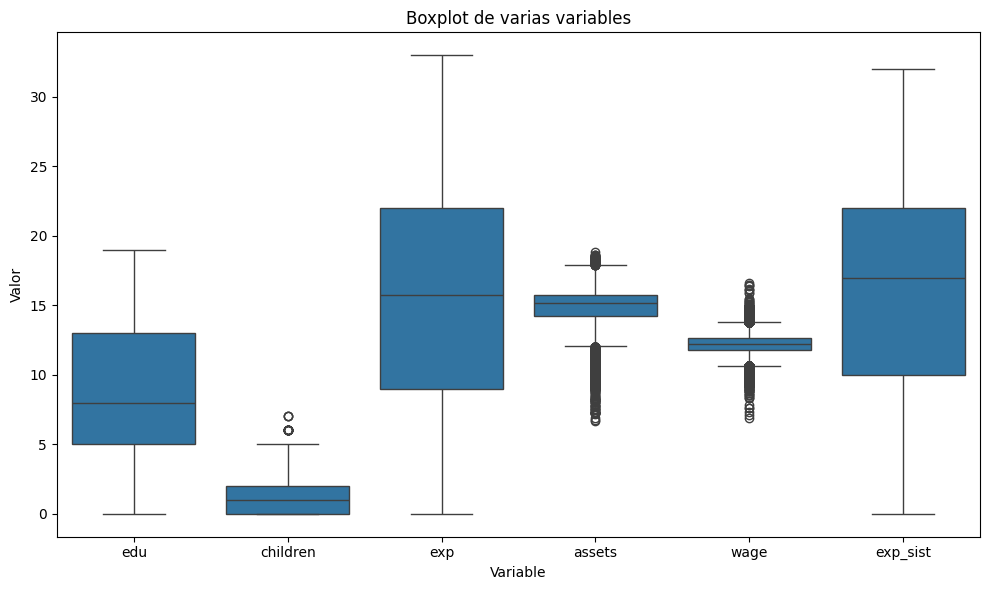

In [12]:
variables = ['edu','children','exp','assets','wage','exp_sist']  # Reemplaza con tus nombres de columnas

# Derretimos el DataFrame para convertir columnas en filas
df_melted = df[variables].melt(var_name='Variable', value_name='Valor')

# Graficamos
plt.figure(figsize=(10, 6))
sns.boxplot(x='Variable', y='Valor', data=df_melted)
plt.title('Boxplot de varias variables')
plt.tight_layout()
plt.show()

In [13]:
cols = ['children', 'assets', 'wage']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [14]:
# Contar observaciones por persona
obs_por_persona = df.groupby("folio_n20").size()
df["obs_count"] = df["folio_n20"].map(obs_por_persona)
df["peso"] = 1 / df["obs_count"]
df.columns = df.columns.str.replace('.', '_', regex=False)

## Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado

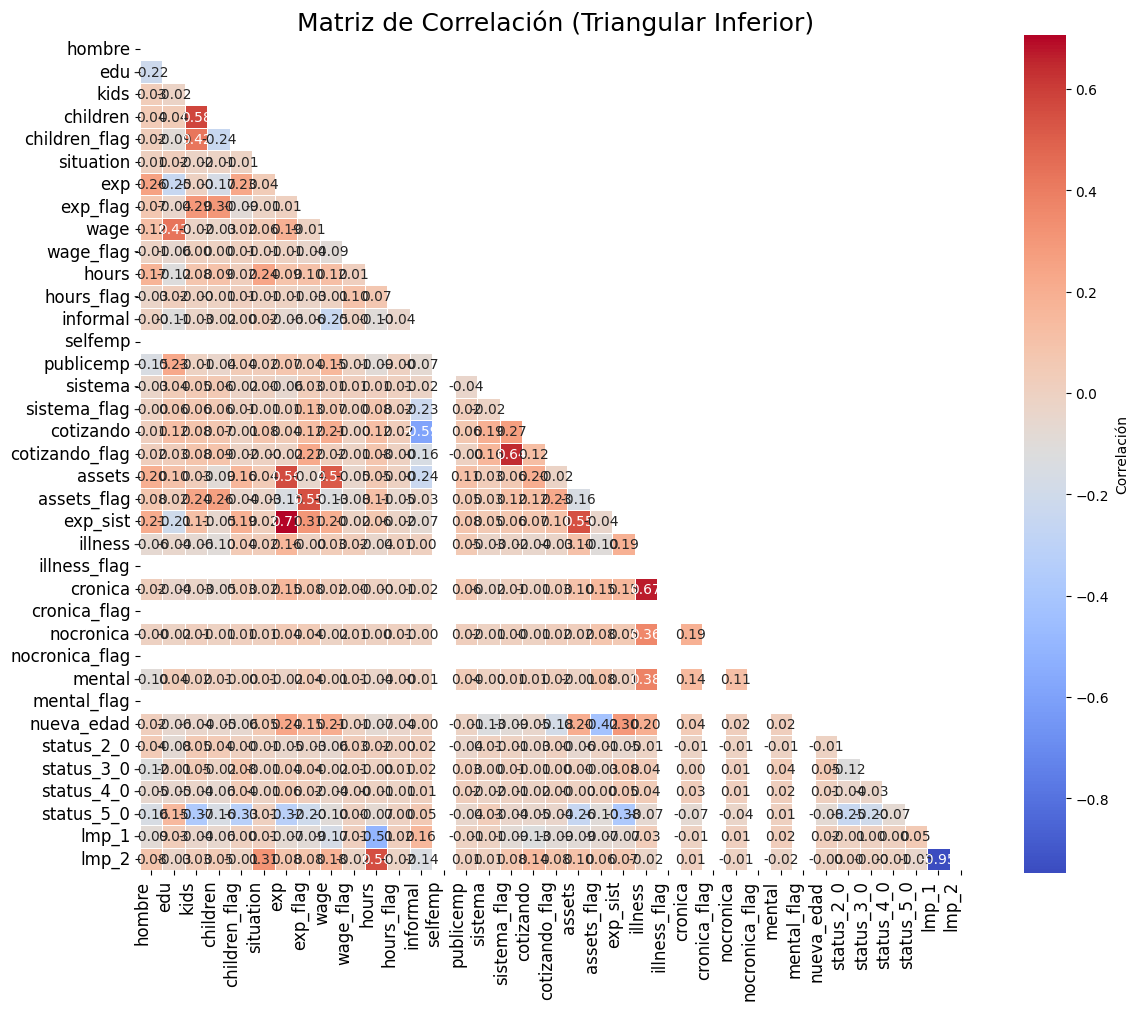

In [15]:

# Lista de variables directamente
variables = ["hombre",
    'edu', 'kids', 'children', 'children_flag', 'situation',
    'exp', 'exp_flag', 'wage', 'wage_flag', 'hours', 'hours_flag',
    'informal', 'selfemp', 'publicemp', 'sistema', 'sistema_flag',
    'cotizando', 'cotizando_flag', 'assets', 'assets_flag', 'exp_sist',
    'illness', 'illness_flag', 'cronica', 'cronica_flag', 'nocronica',
    'nocronica_flag', 'mental', 'mental_flag', 'nueva_edad',
    'status_2_0', 'status_3_0', 'status_4_0', 'status_5_0',
    'lmp_1', 'lmp_2'
]

# Crear la matriz de correlación
corr = df[variables].corr()

# Crear una máscara para mostrar solo la parte triangular inferior de la matriz
mask = np.triu(np.ones_like(corr, dtype=bool))  # np.triu genera la parte superior de la matriz

# Crear el mapa de calor
plt.figure(figsize=(12, 10))  # Ajustar tamaño de la figura

# Heatmap con máscara para mostrar solo la parte inferior triangular
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, 
            linewidths=0.5, annot_kws={"size": 10}, 
            mask=mask, cbar_kws={'label': 'Correlación'}, square=True)

# Título y etiquetas con mayor tamaño de fuente
plt.title('Matriz de Correlación (Triangular Inferior)', fontsize=18)

# Rotar las etiquetas para que se vean mejor
plt.xticks(rotation=90, ha='right', fontsize=12)
plt.yticks( ha='right', fontsize=12)

# Mostrar gráfico
plt.tight_layout()  # Ajusta automáticamente los márgenes para que no se sobrepongan
plt.show()

In [16]:
X = df[["hombre","time","edu","children",'status_2_0', 'status_3_0', 'status_4_0', 'status_5_0',
        'lmp_1', 'lmp_2', "nocronica", 'mental', 'nueva_edad', 'illness_flag', "illness", "cronica",
        'cotizando_flag', "cotizando", 'assets_flag', "assets", "sistema", 'sistema_flag', "publicemp",
        "informal", "hours_flag", "hours", "wage", "exp", "exp_flag", "children_flag", 'kids']]

X = sm.add_constant(X)  # Agregar término de intercepto
Y = df['expectancy']  # Variable dependiente

# Estimación del modelo Pooled OLS
pooled_ols_model = sm.OLS(Y, X).fit()

# Mostrar los resultados
print(pooled_ols_model.summary())



                            OLS Regression Results                            
Dep. Variable:             expectancy   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     151.6
Date:                Tue, 20 May 2025   Prob (F-statistic):               0.00
Time:                        20:53:17   Log-Likelihood:            -1.7468e+05
No. Observations:               26660   AIC:                         3.494e+05
Df Residuals:                   26629   BIC:                         3.497e+05
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
hombre             0.0753      2.448      0.

R. Para desarrolar el modelo, primero se eliminaron variables conflictivas, estas fueron: selfemp, exp_sist y situation.
Viendo el analisis del PooledOLS, observamos un $R^2$ de 0,146 lo cual solo un 15%  de la variabilidad de la expectativa de vida pueden ser explicados, lo cual es bajo. Viendo las variables, podemos observar que son significativas time, con un coeficiente de 56, indica que a mayor periodo la muestra encuestada tiende a tener mayores espectativas de vida, posiblemente por el avance de la medicina/tecnologia; mental de la misma manera indica que si tiene alguna enfermedad mental tiende a tener una expectativa de 28 años menos. La variable edu, que era la interesante en este modelo resulto ser significativa, con una influencia pequeña de que a mayor cantidad de años de estudio menor esperanza de vida. Otra variable es edad, la cual mientras mayor sea aumenta la expectativa de vida 3 años. Illness indica que si esta enfermo tiene menor expectativa de vida en 9 años. En general las variables flag que fueron significativas indican que si el dato es imputado la expectativa de vida es casi nula.
Este modelo guia a un analisis detallado del comportamiento de los individuos muestreados, pero al considerar una muestra transversal simple sera mejor realizar otros modelos.

## Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

Se transforman las variables_flag para marcar la interaccion entre su variable y el indicador. Se elimino la variable hombre, ya que era continua.

In [17]:
# Lista de variables base (sin "_flag")
vars_base = [
    'edu', 'children', 'exp', 'wage', 'hours',
    'sistema', 'cotizando', 'assets',
    'cronica', 'nocronica', 'mental'
]

for var in vars_base:
    flag = f"{var}_flag"
    # Verificamos que ambas columnas existan en X para evitar errores
    if var in df.columns and flag in df.columns:
        # Reemplazamos la variable flag por la interacción
        df[flag] = df[var] * df[flag]

In [18]:
# 1. Establecer índice de panel
df_model = df.set_index(['folio_n20', 'time'])

# 2. Definir variables explicativas y dependiente
X = df_model[["edu","children",'status_2_0', 'status_3_0', 'status_4_0', 'status_5_0','lmp_1', 'lmp_2',"nocronica", 'mental', 'nueva_edad','illness_flag',"illness","cronica"
              ,'cotizando_flag',"cotizando",'assets_flag',"assets","sistema",'sistema_flag',"publicemp","informal","hours_flag","hours","wage","exp","exp_flag",
              "children_flag",'kids']]
X=sm.add_constant(X)
Y = df_model['expectancy']
weights = df_model['peso']  # pesos con el mismo índice de panel

# 4. Ajustar el modelo con efectos fijos y pesos
modelo = PanelOLS(Y, X, weights=weights, entity_effects=True)
results_fe = modelo.fit()

# 5. Ver resultados
print(results_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.1964
Estimator:                   PanelOLS   R-squared (Between):             -1.6890
No. Observations:               26660   R-squared (Within):               0.1964
Date:                Tue, May 20 2025   R-squared (Overall):             -0.7629
Time:                        20:53:18   Log-likelihood                -1.622e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      165.19
Entities:                       12584   P-value                           0.0000
Avg Obs:                       2.1186   Distribution:                F(28,14048)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             122.61
                            

R. El modelo de efectos fijo nos indica que el 19% de la variabilidad de la expectativa de vida es explicada con el modelo, lo cual es mejor que el modelo anterior, tenemos de variables significativas edad, la cual a mayor edad, se espera que la expectativa de vida sea mayor, assets nos dice que mientras mas dinero en el fondo de pension mayor la expectativa de vida, con su indicador vemos que si la variable fue imputada este efecto es menor, hours nos dice que mientras mas años trabajando mayor sera la expectativa de vida, posiblemente por tener más dinero. La variable edu no fue significativa, la cual era importante en este modelo, por lo que se probara el de efectos aleatorios.

## Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado

In [19]:
# Asegúrate de establecer el índice primero
df_model = df.set_index(['folio_n20', 'time'])

# 2. Definir variables explicativas y dependiente
X = df_model[["edu","children",'status_2_0', 'status_3_0', 'status_4_0', 'status_5_0','lmp_1', 'lmp_2',"nocronica", 'mental', 'nueva_edad','illness_flag',"illness","cronica"
              ,'cotizando_flag',"cotizando",'assets_flag',"assets","sistema",'sistema_flag',"publicemp","informal","hours_flag","hours","wage","exp","exp_flag",
              "children_flag",'kids']]
X=sm.add_constant(X)
Y = df_model['expectancy']
weights = df_model['peso']  # pesos con el mismo índice de panel

# Estimar modelo de efectos aleatorios
model = RandomEffects(Y, X, weights=weights)
results_re = model.fit()

# Mostrar resultados
print(results_re.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.0846
Estimator:              RandomEffects   R-squared (Between):              0.0406
No. Observations:               26660   R-squared (Within):               0.1301
Date:                Tue, May 20 2025   R-squared (Overall):              0.0846
Time:                        20:53:20   Log-likelihood                -1.734e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      98.462
Entities:                       12584   P-value                           0.0000
Avg Obs:                       2.1186   Distribution:                F(28,26631)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             87.846
                            

R.  Hay precencia de un r2 menos que el de efectos fijos. 
En este modelo fue significativo edu, con un coeficiente de -1,4 indica que a mayor niveles de estudio menor expectativa de vida, las variables flag indican en su mayoria que las variables inputadas tienen menores expectativas de vida, menos cotizando y assets; children indica que tener hijos produce menor expectativa de vida, status5 en este modelo fue significativa y nos dice que si es soltero tiene mayor espectativa de vida, podria relacionarse con children, los lmp son significativos e indican que si la persona trabaja tiene mayor espectativa de vida, edad lo mismo que los modelos anteriores, a mayor, mayor expectativa; de manera extraña en este caso al tener una enfermedad cronica aumenta la expectativa de vida en 28 años, Cotizando y assets en este caso son negativas y su indicador positivo, puede que haya sido afectado por los valores imputados. Hours nos dice que a mayor cantidad de trabajo mayor expectativa de vida en 3 años, y su indicador nos dice que los datos imputados tuvieron expectativas de vida menor. Wage y exp en este modelo fueron significativas y producen mayor expecativa.

## Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [20]:
hausman_test = compare({'Fixed Effects': results_fe, 'Random Effects': results_re})
print(hausman_test)

b_fe = results_fe.params
b_re = results_re.params

V_fe = results_fe.cov
V_re = results_re.cov

# Coincidir las variables comunes entre ambos modelos
common_vars = b_fe.index.intersection(b_re.index)

# Diferencias en coeficientes y matrices de covarianza
b_diff = b_fe[common_vars] - b_re[common_vars]
V_diff = V_fe.loc[common_vars, common_vars] - V_re.loc[common_vars, common_vars]

# Cálculo del estadístico de Hausman
stat = b_diff.T @ np.linalg.inv(V_diff) @ b_diff
data = len(b_diff)  # grados de libertad
pval = 1 - stats.chi2.cdf(stat, data)

print(f"Hausman chi² = {stat:.2f}, df = {data}, p-value = {pval:.4f}")

                    Model Comparison                    
                         Fixed Effects    Random Effects
--------------------------------------------------------
Dep. Variable               expectancy        expectancy
Estimator                     PanelOLS     RandomEffects
No. Observations                 26660             26660
Cov. Est.                   Unadjusted        Unadjusted
R-squared                       0.1964            0.0846
R-Squared (Within)              0.1964            0.1301
R-Squared (Between)            -1.6890            0.0406
R-Squared (Overall)            -0.7629            0.0846
F-statistic                     165.19            98.462
P-value (F-stat)                0.0000            0.0000
=====================     ============   ===============
edu                             0.0036           -1.4034
                              (0.0048)         (-5.6098)
children                       -0.2692           -4.5209
                             (-

R. Las diferencias nacen de las particularidades de los modelos, el pooledOls trata la data ignorando la estructura de panel, el de efectos fijos controla las caracteristicas no observadas constantes en el tiempo controlando heterogeneidad, y el de efectos aleatorios asume que las diferencias son aleatorias y no correlacionadas, con las variable independiente. Las principales diferencias fueron que en el pooledols y efecto aleatorio la variable edu fue significativa, tambien en los modelos las variables fueron significativas en uno y en otro no, como wage que solo fue significativa en efecto aleatorio y hours en esta misma y pooled ols; y mental fue significativa en efectos fijos y pooledOls. Segun el test de Hausman, deberiamos quedarnos con el modelo de efectos fijos, sin embargo en este modelo edu no fue significativa, si bien explica mejor el comportamiento de las otras variables, edu, que era la importante en este analisis fue descartada, por ello yo me quedaria con efectos aleatorios. Las variables que permanecieron significativas fueron assets, hours,cotizando y edad, considerando solo los ultimos 2 modelos.

## Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

Se eliminó illnes_flag por problemas de correlacion 

In [21]:
df_model = df.set_index(['folio_n20', 'time'])

# 2. Definir variables explicativas y dependiente
X = df_model[["edu","children",'status_2_0', 'status_3_0', 'status_4_0', 'status_5_0','lmp_1', 'lmp_2',"nocronica", 'mental', 'nueva_edad',"illness","cronica"
              ,'cotizando_flag',"cotizando",'assets_flag',"assets","sistema",'sistema_flag',"publicemp","informal","hours_flag","hours","wage","exp","exp_flag",
              "children_flag",'kids']]

Y = df_model['expectancy']

weights = df_model['peso']  # pesos con el mismo índice de panel

# 1. Calcular medias por entidad (términos de Mundlak)
df_means = df_model.groupby('folio_n20')[X.columns].transform('mean')

# Renombrar las columnas para indicar que son las medias
df_means.columns = [col + "_mean" for col in X.columns]

# 2. Añadir los promedios al DataFrame
df_modelo = pd.concat([df_model, df_means], axis=1)

# 3. Definir Y y X incluyendo las medias
y = df_modelo['expectancy']
X = pd.concat([X, df_means], axis=1)  # Concatenar las variables originales con las medias

# 4. Estimar el modelo de efectos aleatorios (RE) con términos de Mundlak
model = RandomEffects(y, X, weights=weights)
results = model.fit(cov_type="robust")

# Mostrar los resultados
print(results.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3797
Estimator:              RandomEffects   R-squared (Between):              0.4774
No. Observations:               26660   R-squared (Within):               0.1964
Date:                Tue, May 20 2025   R-squared (Overall):              0.3797
Time:                        20:53:22   Log-likelihood                -1.729e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      290.77
Entities:                       12584   P-value                           0.0000
Avg Obs:                       2.1186   Distribution:                F(56,26604)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             1538.9
                            

R. Este modelo es el cual hay mejor explicacion de las variables con un $R^2$ de aproximadamente 38%, en este modelo fue significativo las variables: edad la cual si aumenta, aumenta la expectativa de vida,mental la cual reduce la expectativa de vida, illness la cual reduce expectativa de vida, pero en menor medida que mental,assets la cual disminuyte la expecativa de vida y hours la cual lo aumenta.
Además, el modelo permite diferenciar los efectos entre individuos. En este nivel, se observa que un mayor promedio de edad en un grupo se asocia con menor expectativa de vida, mientras que variables como enfermedad mental, enfermedad y activos muestran un efecto positivo, y las horas trabajadas un efecto negativo. Este contraste entre efectos dentro y entre individuos, particularmente en el caso de la edad, puede interpretarse como el reflejo de factores no observados: mientras los individuos mayores podrían esperar vivir más conforme envejecen (por percepción o cuidado personal), los grupos con mayor edad promedio tienden a mostrar una menor expectativa de vida debido a condiciones estructurales o cohortes con peores condiciones.
Si bien este modelo presenta la mejor capacidad explicativa y mayor robustez frente a los otros estimados, es importante destacar que la variable edu, que motivó inicialmente el análisis, no resultó ser significativa en la explicación de la expectativa de vida.

## Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

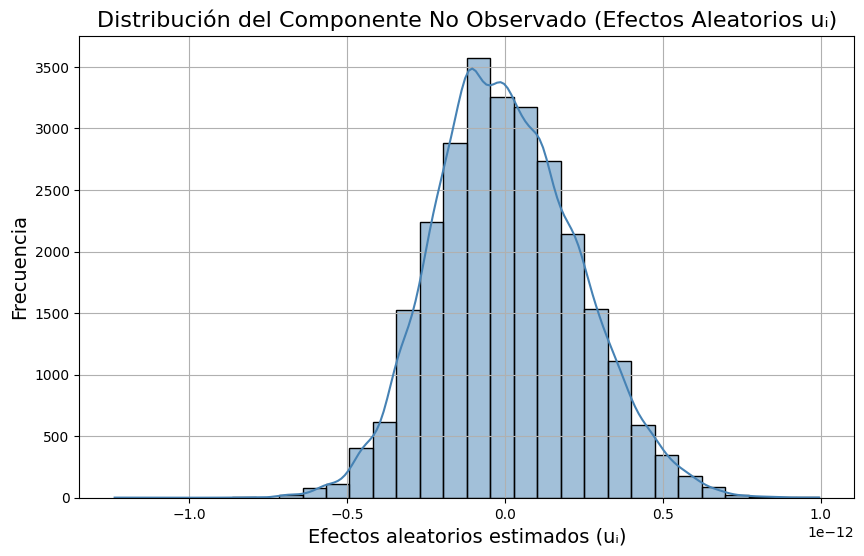

In [22]:
# Extraer los efectos aleatorios estimados
u_i = results.estimated_effects

# Si es un DataFrame multiíndice, quitar nivel 'time'
u_i = u_i.droplevel('time')

# Renombrar la columna para claridad
u_i.columns = ['random_effect']

# Graficar la distribución
plt.figure(figsize=(10, 6))
sns.histplot(u_i['random_effect'], kde=True, color="steelblue", bins=30)
plt.title("Distribución del Componente No Observado (Efectos Aleatorios uᵢ)", fontsize=16)
plt.xlabel("Efectos aleatorios estimados (uᵢ)", fontsize=14)
plt.ylabel("Frecuencia", fontsize=14)
plt.grid(True)
plt.show()

A partir de que la media del componente no observado estimado se encuentra aproximadamente en cero y su forma se asemeja a una distribución acampanada, se puede inferir que los efectos aleatorios siguen una distribución normal, tal como lo asume el modelo. Aunque existe cierta dispersión hacia los extremos, esta es reducida.

Esto indica que la mayor parte de las diferencias individuales no observadas entre personas son pequeñas, por lo que el efecto del componente no observado sobre la variable dependiente (expectativa de vida) es limitado. En consecuencia, el modelo logra explicar una proporción importante de la heterogeneidad entre individuos a través de las variables observadas.

Por tanto, es correcto afirmar que el modelo captura de manera adecuada la influencia de las covariables incluidas en la expectativa de vida de las personas. 

## Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

A partir del test de Hausman, se concluyó que el modelo de efectos aleatorios convencional no era adecuado, debido a que las variables explicativas están correlacionadas con el efecto no observado. Por esta razón, opto por utilizar el modelo de efectos aleatorios correlacionados, el cual permite capturar dicha correlación incluyendo los promedios entre individuos de las variables explicativas.

Este enfoque combina las ventajas de los modelos de efectos fijos y aleatorios, proporcionando estimaciones más eficientes y permitiendo interpretar tanto la variación entre como la dentro de los individuos. Aunque la variable edu (que inicialmente motivó el análisis) no resultó ser significativa, el modelo permitió identificar otros factores que influyen significativamente en la expectativa de vida, como la edad, salud mental, afiliación al sistema de cotización y tenencia de activos. Estos resultados contribuyen empíricamente a una mejor comprensión de los determinantes de la expectativa de vida.

En caso de que el objetivo principal hubiese sido únicamente estimar el efecto de los años de educación sobre la expectativa de vida, habría sido más apropiado utilizar un modelo que garantizara la significancia de esa variable, incluso a costa de menor ajuste general. No obstante, dado que el interés era comprender globalmente los factores que inciden en la expectativa de vida, el modelo de efectos aleatorios correlacionados resulta ser el más adecuado.

En general, las variables que mostraron mayor robustez a lo largo de los distintos modelos coincidieron con aquellas que resultaron significativas en el modelo seleccionado. A partir de esto, se puede inferir que, a nivel individual, una persona de mayor edad podría tener una expectativa de vida más alta debido a una mayor valoración del futuro o hábitos más saludables; en cambio, quienes padecen enfermedades tienden a tener una visión más pesimista sobre su futuro, reduciendo así su expectativa de vida. Asimismo, trabajar más horas podría estar asociado a una mayor esperanza en la continuidad del bienestar personal. Sin embargo, cuando se analizan los efectos entre grupos de individuos, estos patrones se invierten: en promedio, los grupos con mayor edad tienden a proyectar una expectativa de vida más baja, probablemente por condiciones estructurales o acumulación de riesgos; las personas con enfermedades podrían, en ese contexto colectivo, estar recibiendo más apoyo o atención, elevando su expectativa; y en el caso de las horas trabajadas, un mayor promedio puede estar asociado a desgaste y menor calidad de vida, reduciendo así la expectativa esperada.


## Bonus track (optativo): Es posible que sus resultados anteriores tengan sesgo dado que quienes esperan vivir mas pueden estar incentivados a adquirir mas educacion. Proponga AL MENOS DOS instrumentos posibles para predecir el nivel de educacion de forma exogena, tal que se pueda corregir el sesgo y entender el efecto causal de las educacion en la expectativa de vida. Realice su estimacion considerando un modelo agrupado (ignorando el tiempo), y el modelo de panel.